## Connect to Database and pull data

In [14]:
!pip install pymysql
!pip install boto3
!pip install sqlalchemy
!pip install python-dotenv

In [33]:
# package for env variables in google colab: https://pypi.org/project/colab-env/
!pip install colab-env -qU
import colab_env

In [16]:
from colab_env import envvar_handler # modify env variables in var.env file in google drive

In [73]:
import pymysql
import sys
import boto3
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [85]:
connection = pymysql.connect(
    host=os.getenv("AWS_DATABASE_ENDPOINT"),
    user=os.getenv("AWS_USER"),
    port=int(os.getenv("AWS_PORT")),
    passwd=os.getenv("AWS_PASSWORD"),
    database=os.getenv("AWS_DBNAME")
)

In [47]:
with connection.cursor() as cursor:
    cursor.execute("SHOW TABLES")
    tables = cursor.fetchall()

# Print table names
for table in tables:
    print(table[0])

SuperBowl_coinTosses
UC_salaries_data
google_elev_68sites
iris_data


In [ ]:
# from sqlalchemy import select
# stmt = select(user_table).where(user_table.c.name == "spongebob")
# print(stmt)

In [86]:
# years: 2010-2014
# 3024476 rows
# features: row_names	id	year	location	first.name	last.name	title	gross.pay	regular.pay	overtime.pay	other.pay
# location: DIVISION OF AGRICULTURE AND NATURAL RESOURCES (DANR)
# UCOP: university california office of the president
avg_loc_pay_df = pd.read_sql("SELECT location, AVG(`gross.pay`) FROM UC_salaries_data GROUP BY location", con=connection)
avg_loc_pay_df

<ipython-input-86-f645626e0120>:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  avg_loc_pay_df = pd.read_sql("SELECT location, AVG(`gross.pay`) FROM UC_salaries_data GROUP BY location", con=connection)


,location,AVG(`gross.pay`)
0,Santa Cruz,26480.185848
1,Berkeley,33418.287407
2,DANR,34808.033162
3,Davis,48795.614970
4,Irvine,44389.647911
5,Los Angeles,51069.148947
6,Merced,28558.416354
7,Riverside,29015.387886
8,San Diego,48018.481947
9,San Francisco,82919.020569


In [70]:
df_full_pay = pd.read_sql("SELECT location, `gross.pay` FROM UC_salaries_data", con=connection)

<ipython-input-70-6187a36ae24c>:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_full_pay = pd.read_sql("SELECT location, `gross.pay` FROM UC_salaries_data", con=connection)


In [72]:
df_full_pay.head()

,location,gross.pay
0,Santa Cruz,74511.10
1,Berkeley,5369.42
2,Berkeley,4802.00
3,Berkeley,3409.01
4,Berkeley,11673.90


<Axes: xlabel='gross.pay', ylabel='Count'>

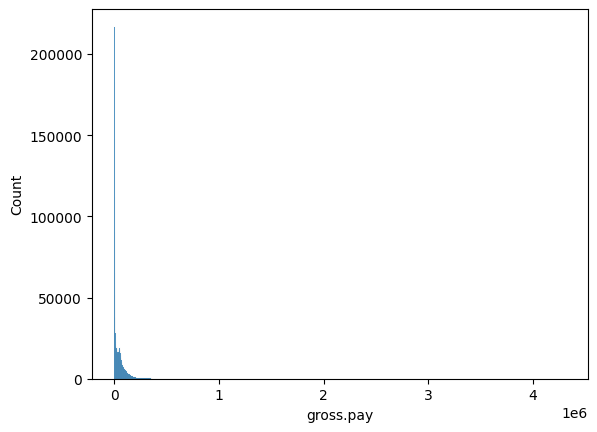

In [74]:
sns.histplot(data=df_full_pay, x="gross.pay")

In [77]:
df_full_pay['gross.pay'].describe()
# mean: 47k
# min: 1? probably error
# 25% quantile: 4k
# 50% quantile: 27k
# 75% quantile: 64k
# max: 4million

,gross.pay
count,3.024474e+06
mean,4.717229e+04
std,6.665361e+04
min,1.000000e+00
25%,4.204000e+03
50%,2.691232e+04
75%,6.401900e+04
max,4.313333e+06


In [82]:
# who is the 4 million salary?
df = pd.read_sql("SELECT location, title, `gross.pay` FROM UC_salaries_data WHERE `gross.pay` > 1000000 ORDER BY `gross.pay` DESC", con=connection)
df

<ipython-input-82-d890f8548827>:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT location, title, `gross.pay` FROM UC_salaries_data WHERE `gross.pay` > 1000000 ORDER BY `gross.pay` DESC", con=connection)


,location,title,gross.pay
0,Los Angeles,HEAD COACH 5,4313333.0
1,Los Angeles,INTERCOL ATH HEAD COACH EX,4248493.0
2,Los Angeles,INTERCOL ATH HEAD COACH EX,3689042.0
3,Los Angeles,HEAD COACH 5,3606667.0
4,Los Angeles,INTERCOL ATH HEAD COACH EX,3577299.0
...,...,...,...
481,Irvine,PROF OF CLIN-HCOMP,1000456.0
482,Los Angeles,HS CLIN PROF-HCOMP,1000452.0
483,Los Angeles,HS CLIN PROF-HCOMP,1000217.0
484,San Francisco,PROF IN RES-HCOMP,1000173.0
